In [ ]:
"""

Evaluating IPSL-CM7 simulations

"""

In [16]:
import xarray as xr
import basal_melt_NEMO.metrics_functions as mf
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
sns.set_context('paper')

In [ ]:
%matplotlib qt5

In [2]:
inputpath = '/thredds/tgcc/store/burgardc/FORMATTED/'
mask_path = '/data/cburgard/TOOLS/'
inputpath_interim='/data/cburgard/PREPARE_FORCING/PREPARE_PRESCRIBED_MELT/interim/'


In [3]:
### FILE T PREPARATION

In [4]:
file_T_list = []

for yy in range(5,9):
    file_T = xr.open_mfdataset(inputpath + 'opencav-presc02_18'+str(yy)+'00101_18'+str(yy)+'91231_1M_grid_T_varofint.nc')
    file_T_list.append(file_T)

file_T_all = xr.concat(file_T_list, dim='time_counter').rename({'time_counter':'time'})

In [5]:
### FILE U PREPARATION

In [6]:
file_U_list = []

for yy in range(5,9):
    file_U = xr.open_mfdataset(inputpath + 'opencav-presc02_18'+str(yy)+'00101_18'+str(yy)+'91231_1M_grid_U_varofint.nc')
    file_U_list.append(file_U)

file_U_all = xr.concat(file_U_list, dim='time_counter').rename({'time_counter':'time'})

In [7]:
### FILE V PREPARATION

In [8]:
file_V_list = []

for yy in range(5,9):
    file_V = xr.open_mfdataset(inputpath + 'opencav-presc02_18'+str(yy)+'00101_18'+str(yy)+'91231_1M_grid_V_varofint.nc')
    file_V_list.append(file_V)

file_V_all = xr.concat(file_V_list, dim='time_counter').rename({'time_counter':'time'})

In [9]:
mask_land_3D = file_T_all['so'].isel(time=0)

In [10]:
cellarea = file_T_all['cell_area'].isel(time=0).where(mask_land_3D > 0).drop('time')


In [11]:
u_vertsum_open = (file_U_all['uocetr_eff'] * (mask_land_3D.rename({'deptht':'depthu'}) > 0)).sum('depthu')

In [12]:
ocean_masks = xr.open_dataset(mask_path + 'basin_masks_orca1_nemo4p2.nc')
isf_masks = xr.open_dataset(inputpath_interim + 'masks_for_eORCA1_prescribedmeltinopencav.nc')

In [13]:
mask_open = isf_masks['mask_isf_open']

In [14]:
ID_open_list = [21,66,67,117,124,125,127,128]

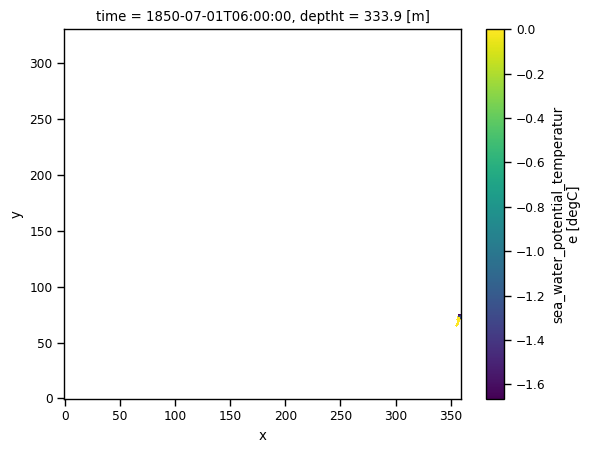

In [22]:
file_T_all['thetao'].isel(time=0,deptht=35).where(mask_open == kisf).plot()

In [28]:
(mask_land_3D)

<xarray.DataArray 'so' (deptht: 75, y: 331, x: 360)>
dask.array<getitem, shape=(75, 331, 360), dtype=float32, chunksize=(75, 331, 360), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 1850-07-01T06:00:00
    nav_lon  (y, x) float32 73.5 74.5 75.5 76.5 77.5 ... -1.0 -1.0 -1.0 -1.0
    nav_lat  (y, x) float32 -84.21 -84.21 -84.21 -84.21 ... -1.0 -1.0 -1.0 -1.0
  * deptht   (deptht) float32 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_water_practical_salinity
    long_name:           sea_water_salinity
    units:               1e-3
    cell_measures:       area: cell_area
    cell_methods:        time: mean time_counter: mean
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month

In [29]:
mask_open == kisf

<xarray.DataArray 'mask_isf_open' (y: 331, x: 360)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
    lat      (y, x) float64 ...
    lon      (y, x) float64 ...
Dimensions without coordinates: y, x

In [31]:
#Tmean cav
#Smean cav

for kisf in ID_open_list:
    mean_T_cav = file_T_all['thetao'].where((mask_land_3D) & (mask_open == kisf)).mean(['deptht','x','y'])
    mean_S_cav = file_T_all['so'].where((mask_land_3D) & (mask_open == kisf)).mean(['deptht','x','y'])

    plt.figure()
    mean_T_cav.plot()
    plt.title('Mean T in cavity '+str(kisf))
    sns.despine()

    plt.figure()
    mean_S_cav.plot()
    plt.title('Mean S in cavity '+str(kisf))
    sns.despine()

TypeError: operand type(s) all returned NotImplemented from __array_ufunc__(<ufunc 'bitwise_and'>, '__call__', dask.array<getitem, shape=(75, 331, 360), dtype=float32, chunksize=(75, 331, 360), chunktype=numpy.ndarray>, array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]])): 'Array', 'ndarray'

In [23]:
file_T_all

<xarray.Dataset>
Dimensions:            (time: 40, bnds: 2, y: 331, x: 360, nvertex: 4,
                        deptht: 75)
Coordinates:
  * time               (time) datetime64[ns] 1850-07-01T06:00:00 ... 1889-07-...
    nav_lon            (y, x) float32 73.5 74.5 75.5 76.5 ... -1.0 -1.0 -1.0
    nav_lat            (y, x) float32 -84.21 -84.21 -84.21 ... -1.0 -1.0 -1.0
  * deptht             (deptht) float32 0.5058 1.556 ... 5.698e+03 5.902e+03
Dimensions without coordinates: bnds, y, x, nvertex
Data variables:
    time_counter_bnds  (time, bnds) datetime64[ns] dask.array<chunksize=(10, 2), meta=np.ndarray>
    nav_lon_bnds       (time, y, x, nvertex) float32 dask.array<chunksize=(10, 331, 360, 4), meta=np.ndarray>
    nav_lat_bnds       (time, y, x, nvertex) float32 dask.array<chunksize=(10, 331, 360, 4), meta=np.ndarray>
    cell_area          (time, y, x) float32 dask.array<chunksize=(10, 331, 360), meta=np.ndarray>
    deptht_bnds        (time, deptht, bnds) float32 dask.array<chunksize=(10, 75, 2), meta=np.ndarray>
    thetao             (time, deptht, y, x) float32 dask.array<chunksize=(10, 75, 331, 360), meta=np.ndarray>
    so                 (time, deptht, y, x) float32 dask.array<chunksize=(10, 75, 331, 360), meta=np.ndarray>
    iceshelf           (time, y, x) float32 dask.array<chunksize=(10, 331, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    name:         opencav-presc02_1m_grid_T
    description:  Created by xios
    title:        Created by xios
    timeStamp:    2025-Feb-03 22:08:57 GMT
    uuid:         9d162a4b-2a99-408b-9113-090ff00ac576
    LongName:     IPSLCM7.1-LR
    history:      Sat Feb 08 13:45:16 2025: cdo yearmean -selvar,thetao,so,ic...
    NCO:          netCDF Operators version 5.0.1 (Homepage = http://nco.sf.ne...
    frequency:    year
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [ ]:
Tbot cav
Sbot cav
Tbot front
Sbot front
fwf flux (integrated for the open ice shelves)